# Patch-clamp experiment as in Peng et al., 2024 and global connection probability of connectivity matrices

In [1]:
import numpy as np 
import pandas
import conntility as conn
import os
import connalysis
import tqdm

from connalysis.network import classic as nxc

from scipy.spatial import distance
from matplotlib import pyplot as plt

In [2]:
# Connectivity matrix to use
root_path = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"
fn_mat = root_path + "Human_NEWfunct_conmat_filtered_compressed.h5"
M = conn.ConnectivityMatrix.from_h5(fn_mat)

## Patch sample and analysis helpers

Functions to patch sample and evaluate triads and connection probabilities

In [3]:
def partition_model_into_subvolumes(M, decomposition_plane, decomposition_sz, min_column_sz):
    grps = conn.circuit_models.neuron_groups.group_by_grid(M.vertices, decomposition_plane, decomposition_sz)
    grps = grps.groupby("grid-subtarget")["node_ids"].apply(list)

    Ms = []
    for grp in grps:
        m = M.subpopulation(grp)
        if len(m) > min_column_sz:
            Ms.append(m)
    return Ms

In [4]:
col_slc = ["slice_x", "slice_y"]

def number_expected_er(P, N):
    from connalysis.network.topology import triad_combinations
    from scipy.stats import binom
    num_edge_per_triad = np.array([2, 2, 2, 3, 3, 3, 3, 4, 4 ,4 ,4, 5, 6])
    num_edge_per_non_triad = np.array([0, 1, 2])
    non_triad_combinations = np.array([1, 6, 3])

    p_er = triad_combinations * (P ** num_edge_per_triad) * ((1 - P) ** (6 - num_edge_per_triad))
    p_er_non = non_triad_combinations * (P ** num_edge_per_non_triad) * ((1 - P) ** (6 - num_edge_per_non_triad))
    assert np.abs(1 - (p_er.sum() + p_er_non.sum())) < 1E-6

    distr_er = binom(N, (p_er / p_er.sum()))
    return distr_er.mean(), distr_er.std()

def sample_and_count_triads(m, mv_cv, n_patch=12, n_samples=25, slice_thickness=150):
    counts = []
    sum_pairs = 0
    sum_connected = 0
    sum_rc = 0
    delta_rec = []
    delta_con = []
    delta_unc = []
    for _ in tqdm.tqdm(range(n_samples)):
        try:
            s = m.slice(np.random.rand() * np.pi, (np.random.rand() - 0.5) * 50, slice_thickness)
            s = s.patch_sample(n_patch, [0, 0], mv_cv, columns_xy=col_slc)
            sum_pairs += (len(s) * (len(s) - 1))
            sum_connected += s.matrix.nnz
            sum_rc += s.to_reciprocal().matrix.nnz
            counts.append(connalysis.network.topology.count_triads_fully_connected(s.matrix > 0, return_normalized=False))
            D = s.vertices[col_slc].values.reshape((1, -1, 2)) - s.vertices[col_slc].values.reshape((-1, 1, 2))
            delta_rec.append(pandas.DataFrame(
                D[(s.array > 0) & (s.array.transpose() > 0)], columns=["horizontal", "vertical"]
            ))
            delta_con.append(pandas.DataFrame(
                D[(s.array > 0) & (s.array.transpose() == 0)], columns=["horizontal", "vertical"]
            ))
            delta_unc.append(pandas.DataFrame(
                D[(s.array == 0)], columns=["horizontal", "vertical"]
            ))
        except:
            pass
    P = sum_connected / sum_pairs
    Prec = sum_rc / sum_pairs
    deltas = pandas.concat([
        pandas.concat(delta_rec, axis=0, names=["sample"], keys=range(len(delta_rec))),
        pandas.concat(delta_con, axis=0, names=["sample"], keys=range(len(delta_con))),
        pandas.concat(delta_unc, axis=0, names=["sample"], keys=range(len(delta_unc)))
    ], axis=0, keys=["reciprocal", "unidirectional", "unconnected"])
    counts = np.vstack(counts).sum(axis=0)
    return counts, (P, Prec), deltas


Main entry point

In [5]:
def execute_slice_and_patch_campaign(M, param_dict):
    if "decomposition_plane" in param_dict:
        Ms = partition_model_into_subvolumes(M, param_dict["decomposition_plane"],
                                             param_dict["decomposition_sz"], param_dict["min_column_sz"])
    else:
        Ms = [M]
    
    all_counts = []
    all_er = []
    all_deltas = []

    mv_cv = np.array(param_dict["mv_cv"])
    patch_kwargs = param_dict["patch_kwargs"]
    allP_u = []; allP_rc = []
    for m in Ms:
        counts, P, deltas = sample_and_count_triads(m, mv_cv, **patch_kwargs)
        allP_u.append(P[0]); allP_rc.append(P[1])
        count_er_mn, count_er_sd = number_expected_er(P[0], counts.sum())
        all_counts.append((counts - count_er_mn) / count_er_sd)
        all_deltas.append(deltas)

    all_counts = pandas.DataFrame(all_counts,
                     index=pandas.RangeIndex(len(all_counts), name="subvolume"),
                     columns=pandas.RangeIndex(13, name="motif"))
    all_deltas = pandas.concat(all_deltas, axis=0, names=["subvolume"], keys=range(len(all_deltas)))
    return all_counts, all_deltas, pandas.DataFrame({"unidirectional": allP_u,
                                                     "reciprocal": allP_rc})
  

## Patch-clamp experiment

In [6]:
campaign_cfg = {
    "decomposition_plane": ["x", "z"], # What are the horizontal axes of the volume?Decomposition will happen in this plane.
    "decomposition_sz": 250,
    "min_column_sz": 500, # After decomposition, columns smaller than this will be discarded,
    "mv_cv": [[145**2, 0], [0, 150**2]], # Describes the patch sampling spatial dimensions. 40 ** 2 will sample neuron pairs up to ~100 um.
    "patch_kwargs": {
        "slice_thickness": 200,
        "n_samples": 55, # The number of times the patch sampling procedure will be applied
        "n_patch": 12 # Up to this number of neurons will be sampled together
    }
}

all_counts, all_deltas, P = execute_slice_and_patch_campaign(M, campaign_cfg)

 24%|██████████▏                                | 13/55 [00:00<00:00, 60.05it/s]

Testing 35 potential triadic pairs
Time spent finding triads: 0.0006079673767089844
Found 34 connected triads
Time spent classifying triads: 0.0006277561187744141
Testing 59 potential triadic pairs
Time spent finding triads: 0.00026702880859375
Found 106 connected triads
Time spent classifying triads: 0.0009059906005859375
Testing 46 potential triadic pairs
Time spent finding triads: 0.00022292137145996094
Found 46 connected triads
Time spent classifying triads: 0.0003981590270996094
Testing 50 potential triadic pairs
Time spent finding triads: 0.00022721290588378906
Found 65 connected triads
Time spent classifying triads: 0.0005590915679931641
Testing 39 potential triadic pairs
Time spent finding triads: 0.00020694732666015625
Found 38 connected triads
Time spent classifying triads: 0.0003337860107421875
Testing 15 potential triadic pairs
Time spent finding triads: 0.0001850128173828125
Found 13 connected triads
Time spent classifying triads: 0.00013685226440429688
Testing 52 potentia

 36%|███████████████▋                           | 20/55 [00:00<00:00, 61.33it/s]

Testing 34 potential triadic pairs
Time spent finding triads: 0.00023889541625976562
Found 37 connected triads
Time spent classifying triads: 0.0004951953887939453
Testing 39 potential triadic pairs
Time spent finding triads: 0.00021409988403320312
Found 44 connected triads
Time spent classifying triads: 0.0003819465637207031
Testing 36 potential triadic pairs
Time spent finding triads: 0.0002048015594482422
Found 42 connected triads
Time spent classifying triads: 0.0003609657287597656
Testing 54 potential triadic pairs
Time spent finding triads: 0.0002300739288330078
Found 74 connected triads
Time spent classifying triads: 0.0006098747253417969
Testing 31 potential triadic pairs
Time spent finding triads: 0.00019788742065429688
Found 33 connected triads
Time spent classifying triads: 0.0002880096435546875
Testing 21 potential triadic pairs
Time spent finding triads: 0.0001819133758544922
Found 19 connected triads
Time spent classifying triads: 0.00017881393432617188
Testing 36 potenti

 62%|██████████████████████████▌                | 34/55 [00:00<00:00, 63.75it/s]

...

Testing 59 potential triadic pairs
Time spent finding triads: 0.00026798248291015625
Found 78 connected triads
Time spent classifying triads: 0.0010440349578857422
Testing 40 potential triadic pairs
Time spent finding triads: 0.000209808349609375
Found 48 connected triads
Time spent classifying triads: 0.0004048347473144531
Testing 5 potential triadic pairs
Time spent finding triads: 0.0001957416534423828
Found 5 connected triads
Time spent classifying triads: 0.00016188621520996094
Testing 14 potential triadic pairs
Time spent finding triads: 0.00018405914306640625
Found 19 connected triads
Time spent classifying triads: 0.0001838207244873047
Testing 24 potential triadic pairs
Time spent finding triads: 0.00022292137145996094
Found 24 connected triads
Time spent classifying triads: 0.0003228187561035156
Testing 27 potential triadic pairs
Time spent finding triads: 0.00019216537475585938
Found 27 connected triads
Time spent classifying triads: 0.000244140625
Testing 44 potential triadi

 89%|██████████████████████████████████████▎    | 49/55 [00:00<00:00, 64.07it/s]

Testing 52 potential triadic pairs
Time spent finding triads: 0.00026702880859375
Found 66 connected triads
Time spent classifying triads: 0.0007071495056152344
Testing 44 potential triadic pairs
Time spent finding triads: 0.00022125244140625
Found 61 connected triads
Time spent classifying triads: 0.0005142688751220703
Testing 1 potential triadic pairs
Time spent finding triads: 0.00015997886657714844
Found 1 connected triads
Time spent classifying triads: 2.6941299438476562e-05
Testing 33 potential triadic pairs
Time spent finding triads: 0.00023674964904785156
Found 34 connected triads
Time spent classifying triads: 0.0005459785461425781


100%|███████████████████████████████████████████| 55/55 [00:00<00:00, 63.73it/s]

Testing 17 potential triadic pairs
Time spent finding triads: 0.00021696090698242188
Found 21 connected triads
Time spent classifying triads: 0.0002880096435546875
Testing 59 potential triadic pairs
Time spent finding triads: 0.000244140625
Found 95 connected triads
Time spent classifying triads: 0.0008881092071533203


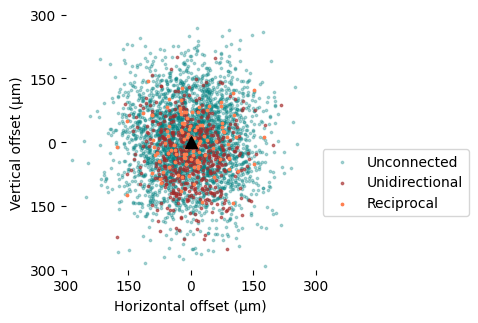

In [7]:
i = 0
d = all_deltas.loc[i]
d["distance"] = np.linalg.norm(d, axis=1)
dists = d.reset_index().groupby("level_0")["distance"].mean()

fig = plt.figure(figsize=(5, 3))
ax = fig.add_axes([0.1, 0.1, 0.5, 0.85])

def sample_random_fraction(arr_in, frac):
    assert frac <= 1
    b = np.random.choice(len(arr_in), int(len(arr_in) * frac), replace=False)
    return arr_in.iloc[b]["horizontal"], arr_in.iloc[b]["vertical"]

cols_use = [[0.6, 0.6, 1.0], [0.1, 0.1, 0.7], [0.9, 0.3, 0.0]]

ax.scatter(*sample_random_fraction(d.loc["unconnected"], 0.5), color='teal', s=3, alpha=0.3, label="Unconnected")
ax.scatter(*sample_random_fraction(d.loc["unidirectional"], 0.5), color='brown', s=3, alpha=0.6, label="Unidirectional")
ax.scatter(*sample_random_fraction(d.loc["reciprocal"], 0.5), color='coral', s=3, alpha=1., label="Reciprocal")
ax.plot(0, 0, marker="^", ms=8, color="black")
ax.set_xlabel("Horizontal offset (µm)")
ax.set_ylabel("Vertical offset (µm)")
ax.set_frame_on(False)
# plt.axis("equal")
ax.set_xlim([-300, 300]); ax.set_xticks([-300, -150, 0, 150, 300]); ax.set_xticklabels([300, 150, 0, 150, 300])
ax.set_ylim([-300, 300]); ax.set_yticks([-300, -150, 0, 150, 300]); ax.set_yticklabels([300, 150, 0, 150, 300])
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
#plt.savefig('patch_clamp_sampling.svg')

Text(0, 0.5, 'Mean distance (µm)')

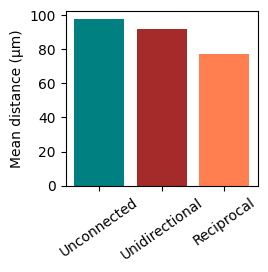

In [8]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_axes([0.725, 0.35, 0.275, 0.35])
ax.bar(2, dists["reciprocal"], color='coral')
ax.bar(1, dists["unidirectional"], color='brown')
ax.bar(0, dists["unconnected"], color='teal')
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Unconnected", "Unidirectional", "Reciprocal"], rotation=35)
ax.set_ylabel("Mean distance (µm)")
#ax.set_frame_on(False)
#plt.savefig('patch_clamp_sampling_barplot.svg')

### Recreating Peng et al 2024 figure 1.B

In [9]:
Peng_values = [0.158102766798419, 0.02661396574440053, 0.024769433465085616] #, 0.032411067193675897]
Peng_labels = ['unidirectionla data', 'reciprocal data', 'reciprocal ER'] #, 'reciprocal het ER']

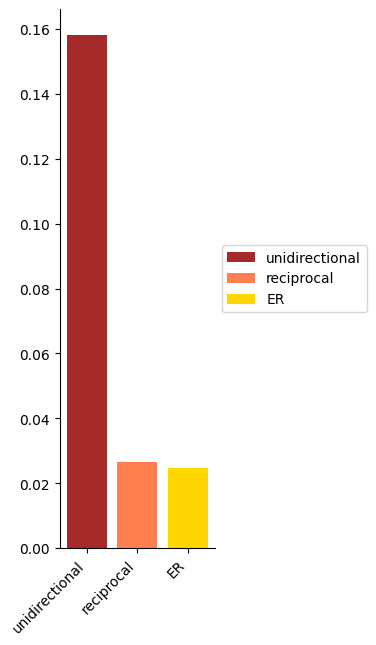

In [10]:
x = [1, 2, 3]
colors = ['brown', 'coral', 'gold']
labels = ['unidirectional', 'reciprocal', 'ER']
plt.figure(figsize=(2,7))
#remove frame from each side of plot
#plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
#plt.rcParams['axes.spines.bottom'] = False

plt.bar(x, Peng_values, color=colors, label=labels, width=0.8)

plt.xticks(x, labels)
plt.xticks(rotation=45, ha="right")
#plt.axis('off')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#plt.savefig('bar_plot_Peng.svg')

### Validate connection probabilites for all connectivity matrices: functional, E_to_T, T_to_T, E_to_E and T_to_E 
To be compared to Peng et al., Figure 1B (dashed lines)

In [11]:
# Loading connectivity matrices

fns = {
    "Functional_human": root_path + "Human_NEWfunct_conmat_filtered_compressed.h5",
    "E_to_T_human": root_path + "Human_pruned_E_to_T_conmat.h5",
    "T_to_T_human": root_path + "Human_pruned_T_to_T_conmat.h5",
    "E_to_E_human": root_path + "Human_pruned_E_to_E_conmat.h5",
    "T_to_E_human": root_path + "Human_pruned_T_to_E_conmat.h5"
}

Ms = dict([(k, conn.ConnectivityMatrix.from_h5(v))
           for k, v in fns.items()])

#### Sampling at scales that resemble Peng et al (see above).

In [12]:
def patch_result_to_con_probs(deltas):
    deltas = deltas[(deltas != 0).any(axis=1)]

    tst = deltas.reset_index().groupby("subvolume")["level_1"].value_counts().unstack("level_1")
    tst["connected"] = tst["reciprocal"] + tst["unidirectional"]
    tst["reciprocal_pairs"] = tst["reciprocal"] / 2 # Because the original analysis counts rc pairs twice, once for each direction
    tst["sorted_pairs"] = tst["connected"] + tst["unconnected"]
    tst["pairs"] = tst["sorted_pairs"] / 2

    count_srt = int(tst["sorted_pairs"][0]) # All samplings have the same number. Just using the first.
    count_unsrt = int(tst["pairs"][0])
    
    return tst, count_srt, count_unsrt

campaign_cfg = {
    "decomposition_plane": ["x", "z"], # What are the horizontal axes of the volume?Decomposition will happen in this plane.
    "decomposition_sz": 250,
    "min_column_sz": 500, # After decomposition, columns smaller than this will be discarded,
    "mv_cv": [[145**2, 0], [0, 150**2]], # Describes the patch sampling spatial dimensions. 40 ** 2 will sample neuron pairs up to ~100 um.
    "patch_kwargs": {
        "slice_thickness": 200,
        "n_samples": 55, # The number of times the patch sampling procedure will be applied
        "n_patch": 12 # Up to this number of neurons will be sampled together
    }
}

df_Ps = []; counts_srt = []; counts_unsrt = []
for k, M in Ms.items():
    counts, deltas, P = execute_slice_and_patch_campaign(M, campaign_cfg)
    df_P, c_srt, c_un = patch_result_to_con_probs(deltas)
    df_Ps.append((k, df_P)); counts_srt.append((k, c_srt)); counts_unsrt.append((k, c_un))
df_Ps = dict(df_Ps); counts_srt = dict(counts_srt); counts_unsrt = dict(counts_unsrt)

 13%|█████▌                                      | 7/55 [00:00<00:00, 64.43it/s]

Testing 30 potential triadic pairs
Time spent finding triads: 0.0002541542053222656
Found 26 connected triads
Time spent classifying triads: 0.0003991127014160156
Testing 59 potential triadic pairs
Time spent finding triads: 0.0002460479736328125
Found 80 connected triads
Time spent classifying triads: 0.0006797313690185547
Testing 42 potential triadic pairs
Time spent finding triads: 0.00021314620971679688
Found 47 connected triads
Time spent classifying triads: 0.0004191398620605469
Testing 63 potential triadic pairs
Time spent finding triads: 0.0002613067626953125
Found 101 connected triads
Time spent classifying triads: 0.000858306884765625
Testing 65 potential triadic pairs
Time spent finding triads: 0.00025081634521484375
Found 98 connected triads
Time spent classifying triads: 0.0008368492126464844
Testing 36 potential triadic pairs
Time spent finding triads: 0.00020503997802734375
Found 40 connected triads
Time spent classifying triads: 0.0003612041473388672
Testing 50 potentia

 38%|████████████████▍                          | 21/55 [00:00<00:00, 63.41it/s]

Time spent classifying triads: 0.0003058910369873047
Testing 54 potential triadic pairs
Time spent finding triads: 0.00025081634521484375
Found 74 connected triads
Time spent classifying triads: 0.0006270408630371094
Testing 53 potential triadic pairs
Time spent finding triads: 0.00025010108947753906
Found 82 connected triads
Time spent classifying triads: 0.0006868839263916016
Testing 56 potential triadic pairs
Time spent finding triads: 0.0002319812774658203
Found 60 connected triads
Time spent classifying triads: 0.0005080699920654297
Testing 39 potential triadic pairs
Time spent finding triads: 0.00021195411682128906
Found 49 connected triads
Time spent classifying triads: 0.0004239082336425781
Testing 47 potential triadic pairs
Time spent finding triads: 0.0002357959747314453
Found 63 connected triads
Time spent classifying triads: 0.0005440711975097656
Testing 42 potential triadic pairs
Time spent finding triads: 0.00021886825561523438
Found 46 connected triads
Time spent classif

 64%|███████████████████████████▎               | 35/55 [00:00<00:00, 63.41it/s]

...

Testing 2 potential triadic pairs
Time spent finding triads: 0.0001819133758544922
Found 2 connected triads
Time spent classifying triads: 4.792213439941406e-05
Testing 14 potential triadic pairs
Time spent finding triads: 0.00019502639770507812
Found 14 connected triads
Time spent classifying triads: 0.00013899803161621094
Testing 47 potential triadic pairs
Time spent finding triads: 0.00021696090698242188
Found 58 connected triads
Time spent classifying triads: 0.0005202293395996094
Testing 21 potential triadic pairs
Time spent finding triads: 0.00018310546875
Found 26 connected triads
Time spent classifying triads: 0.0002551078796386719
Testing 32 potential triadic pairs
Time spent finding triads: 0.00020241737365722656
Found 32 connected triads
Time spent classifying triads: 0.0002868175506591797
Testing 39 potential triadic pairs
Time spent finding triads: 0.0002319812774658203
Found 50 connected triads
Time spent classifying triads: 0.0004496574401855469
Testing 59 potential tria

 89%|██████████████████████████████████████▎    | 49/55 [00:00<00:00, 66.67it/s]

Testing 57 potential triadic pairs
Time spent finding triads: 0.0002961158752441406
Found 69 connected triads
Time spent classifying triads: 0.001132965087890625
Testing 50 potential triadic pairs
Time spent finding triads: 0.00024127960205078125
Found 78 connected triads
Time spent classifying triads: 0.0006680488586425781
Testing 34 potential triadic pairs
Time spent finding triads: 0.000209808349609375
Found 41 connected triads
Time spent classifying triads: 0.00036716461181640625
Testing 16 potential triadic pairs
Time spent finding triads: 0.0001800060272216797
Found 14 connected triads
Time spent classifying triads: 0.0001430511474609375
Testing 48 potential triadic pairs
Time spent finding triads: 0.00022983551025390625
Found 66 connected triads
Time spent classifying triads: 0.0005838871002197266
Testing 53 potential triadic pairs
Time spent finding triads: 0.0002181529998779297
Found 68 connected triads
Time spent classifying triads: 0.0006010532379150391
Testing 26 potential 

100%|███████████████████████████████████████████| 55/55 [00:00<00:00, 66.73it/s]


Testing 33 potential triadic pairs
Time spent finding triads: 0.00023603439331054688
Found 39 connected triads
Time spent classifying triads: 0.00043320655822753906


Total reciprocal over-/under-expression without sampling

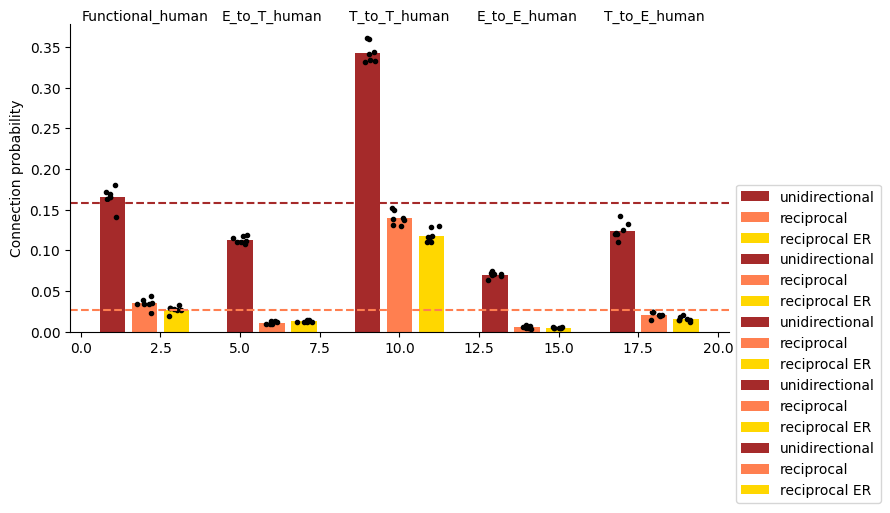

In [13]:
fig = plt.figure(figsize=(1.5 * len(df_Ps) + 1, 4))
low_bars = [0,0,0,0,0]
i = 1
xticks = []; xticklbls = []; ttls = []
for k, df_P in df_Ps.items():
    ax = fig.gca()

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 0 + i
    y = df_P["connected"].sum() / df_P["sorted_pairs"].sum()
    mn = int(df_P["connected"].mean()); sd = int(df_P["connected"].std())
    ax.bar(i, y, color="brown", label="unidirectional")
    #ax.errorbar(i, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, df_P["connected"] / df_P["sorted_pairs"], marker='.', color="black", ls="None")
    #ax.text(i + 0.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count))

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 1 + i
    y = df_P["reciprocal_pairs"].sum() / df_P["pairs"].sum()
    mn = int(df_P["reciprocal_pairs"].mean()); sd = int(df_P["reciprocal_pairs"].std())
    ax.bar(i + 1, y, color="coral", label="reciprocal")
    #ax.errorbar(i+1, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, df_P["reciprocal_pairs"] / df_P["pairs"], marker='.', color="black", ls="None")
    #ax.text(i + 1.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count_b))

    x = 0.5 * (np.random.rand(len(df_P)) - 0.5) + 2 + i
    y = (df_P["connected"].sum() / df_P["sorted_pairs"].sum()) ** 2
    smpls = df_P["pairs"] * (df_P["connected"] / df_P["sorted_pairs"]) ** 2
    mn = int(smpls.mean()); sd = int(smpls.std())
    ax.bar(i + 2, y, color="gold", label="reciprocal ER")
    #ax.errorbar(i+2, y, yerr = sd/df_P["pairs"].sum(), alpha=0.5, fmt=" ", capsize=6, elinewidth=3, color='black')

    ax.plot(x, (df_P["connected"] / df_P["sorted_pairs"]) ** 2, marker='.', color="black", ls="None")
    # ax.text(2.25, y + 0.01, "{0}+-{1}/{2}".format(mn, sd, count_b))
    
    xticks.extend([i, i + 1, i + 2])
    #xticklbls.extend(["unidirectional", "reciprocal", "reciprocal ER"])
    ttls.append(k)
    i = i + 4

#ax.set_xticks(xticks); ax.set_xticklabels(xticklbls, rotation=45)
#ax.set_frame_on(False)
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel("Connection probability")
ax.set_xlim(ax.get_xlim())
ax.plot(ax.get_xlim(), [0.158102766798419, 0.158102766798419], color="brown", ls="--")
ax.plot(ax.get_xlim(), [0.02661396574440053, 0.02661396574440053], color="coral", ls="--")

ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

ymx = ax.get_ylim()[1]
for _ttl, _x in zip(ttls, xticks[1::3]):
    ax.text(_x, ymx, _ttl, horizontalalignment="center", verticalalignment="bottom")
    
#plt.savefig('Connection_Probability_ours_vs_Peng.svg')

## Global connection probability

In [14]:
# Save the rest of the connectivity matrices in Ms dictionary and load them

fns = {
    "Structural_human": root_path + "Human_NEWstruct_conmat_filtered_compressed.h5",
    "Structural_rat": root_path + "Rat_623um_squared_struc_conmat_filtered_compressed.h5",
    "Functional_rat": root_path + "Rat_623um_squared_funct_conmat_filtered_compressed.h5",
    "E_to_T_rat": root_path + "Rat_pruned_E_to_T_conmat.h5",
    "T_to_T_rat": root_path + "Rat_pruned_T_to_T_conmat.h5",
    "E_to_E_rat": root_path + "Rat_pruned_E_to_E_conmat.h5",
    "T_to_E_rat": root_path + "Rat_pruned_T_to_E_conmat.h5",
    "E_to_T_HC_RD": root_path + "humanized_rat_pruned_E_to_T_conmat.h5",
    "T_to_T_HC_RD": root_path + "humanized_rat_pruned_T_to_T_conmat.h5",
    "E_to_E_HC_RD": root_path + "humanized_rat_pruned_E_to_E_conmat.h5",
    "T_to_E_HC_RD": root_path + "humanized_rat_pruned_T_to_E_conmat.h5"
}

for k, v in fns.items():
    Ms[k] = conn.ConnectivityMatrix.from_h5(v)

In [15]:
# Control matrix have a special group_name
Ms["HC_RD"] = conn.ConnectivityMatrix.from_h5(root_path+"third_order_mdl_instances_humanized_rat.h5", "instance1")

In [16]:
Ms_key_list = list(Ms.keys())
Ms_key_list

['Functional_human',
 'E_to_T_human',
 'T_to_T_human',
 'E_to_E_human',
 'T_to_E_human',
 'Structural_human',
 'Structural_rat',
 'Functional_rat',
 'E_to_T_rat',
 'T_to_T_rat',
 'E_to_E_rat',
 'T_to_E_rat',
 'E_to_T_HC_RD',
 'T_to_T_HC_RD',
 'E_to_E_HC_RD',
 'T_to_E_HC_RD',
 'HC_RD']

### Compute global connection probability

In [17]:
density = {}

Ms_key_list = list(Ms.keys())
for k in Ms_key_list:
    adj_mat = Ms[k].matrix
    dens = nxc.density(adj_mat,neuron_properties=[])
    density[k] = dens

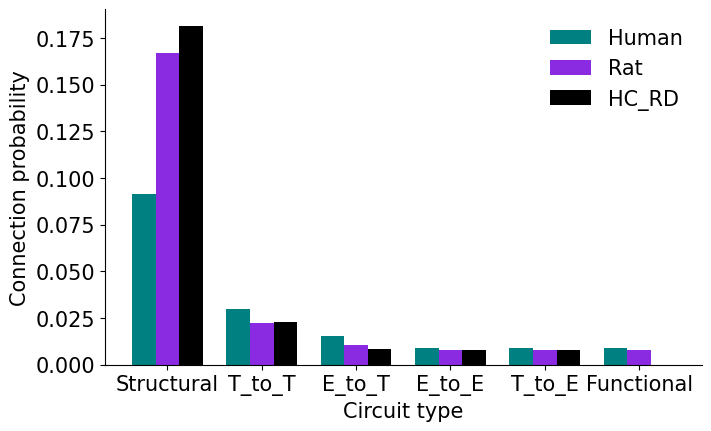

In [18]:
circ_types = ("Structural", "T_to_T", "E_to_T", "E_to_E", "T_to_E", "Functional")
color = ("teal", "blueviolet", "black")
values = {
    'Human': (density['Structural_human'], density['T_to_T_human'], density['E_to_T_human'], density['E_to_E_human'], density['T_to_E_human'], density['Functional_human']),
    'Rat': (density['Structural_rat'], density['T_to_T_rat'], density['E_to_T_rat'], density['E_to_E_rat'], density['T_to_E_rat'], density['Functional_rat']),
    'HC_RD': (density['HC_RD'], density['T_to_T_HC_RD'], density['E_to_T_HC_RD'], density['E_to_E_HC_RD'], density['T_to_E_HC_RD'], 0.0)
}

x = np.arange(len(circ_types))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(7, 4.2))

for c, (attribute, measurement) in zip(color, values.items()):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=c)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('Connection probability', fontsize=15)
ax.set_xlabel('Circuit type', fontsize=15)
#ax.set_title('Connection Probability')
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xticks(x + width, circ_types)
ax.legend(loc='upper right', ncols=1, fontsize=15, frameon=False)


plt.show()
#fig.savefig('connectionProbability_Global.svg', transparent=True, bbox_inches='tight')